# E-Commerce Customer Segmentation

## 1. Business Objective

The goal of this project is to identify different customer segments based on purchasing behavior and determine which customers should receive the greatest business attention.

We use RFM analysis:

- **Recency:** How recently did the customer purchase?
- **Frequency:** How often did the customer purchase?
- **Monetary:** How much did the customer spend?

The analysis will be used to identify high-value, loyal, potential, and at-risk customers.

In [1]:
import pandas as pd

df = pd.read_csv("data/Online Retail.csv")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [2]:
df.shape

(541909, 8)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [4]:
df["InvoiceNo"].astype(str).str.startswith("C").value_counts()

InvoiceNo
False    532621
True       9288
Name: count, dtype: int64

In [5]:
df["Quantity"].describe()

count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

In [6]:
df["UnitPrice"].describe()

count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [7]:
# Missing customer IDs
df["CustomerID"].isna().sum()

np.int64(135080)

In [8]:
# Non-positive quantities
(df["Quantity"] <= 0).sum()

np.int64(10624)

In [9]:
# Non-positive prices
(df["UnitPrice"] <= 0).sum()

np.int64(2517)

In [10]:
# How many rows have cancelled invoices?
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9288)

In [11]:
(df["Quantity"] <= 0).groupby(
    df["InvoiceNo"].astype(str).str.startswith("C")
).sum()

InvoiceNo
False    1336
True     9288
Name: Quantity, dtype: int64

In [12]:
df.loc[df["Quantity"] <= 0, "InvoiceNo"].astype(str).str.startswith("C").value_counts()

InvoiceNo
True     9288
False    1336
Name: count, dtype: int64

In [13]:
df_clean = df[
    df["CustomerID"].notna() &
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
].copy()

In [14]:
df_clean.shape

(397884, 8)

In [15]:
df_clean.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [18]:
df_clean["InvoiceDate"] = pd.to_datetime(
    df_clean["InvoiceDate"],
    format="%d-%m-%Y %H:%M"
)

In [19]:
df_clean[["InvoiceDate", "Quantity", "UnitPrice", "Revenue"]].head()

,InvoiceDate,Quantity,UnitPrice,Revenue
0,2010-12-01 08:26:00,6,2.55,15.30
1,2010-12-01 08:26:00,6,3.39,20.34
2,2010-12-01 08:26:00,8,2.75,22.00
3,2010-12-01 08:26:00,6,3.39,20.34
4,2010-12-01 08:26:00,6,3.39,20.34


In [20]:
print("Customers:", df_clean["CustomerID"].nunique())
print("Orders:", df_clean["InvoiceNo"].nunique())
print("Products:", df_clean["StockCode"].nunique())
print("Countries:", df_clean["Country"].nunique())
print("Total Revenue: £{:,.2f}".format(df_clean["Revenue"].sum()))

Customers: 4338
Orders: 18532
Products: 3665
Countries: 37
Total Revenue: £8,911,407.90


### Clean Dataset

After removing transactions without customer identifiers and transactions with non-positive quantities or prices, the dataset contains:

- **397,884 transactions**
- **4,338 customers**
- **18,532 orders**
- **3,665 products**
- **37 countries**
- **£8.91M total revenue**

In [21]:
df_clean["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [22]:
reference_date = df_clean["InvoiceDate"].max()

recency = df_clean.groupby("CustomerID")["InvoiceDate"].max().apply(
    lambda x: (reference_date - x).days
)

recency.head()

CustomerID
12346.0    325
12347.0      1
12348.0     74
12349.0     18
12350.0    309
Name: InvoiceDate, dtype: int64

In [23]:
frequency = df_clean.groupby("CustomerID")["InvoiceNo"].nunique()

frequency.head()

CustomerID
12346.0    1
12347.0    7
12348.0    4
12349.0    1
12350.0    1
Name: InvoiceNo, dtype: int64

In [24]:
monetary = df_clean.groupby("CustomerID")["Revenue"].sum()

monetary.head()

CustomerID
12346.0    77183.60
12347.0     4310.00
12348.0     1797.24
12349.0     1757.55
12350.0      334.40
Name: Revenue, dtype: float64

In [25]:
monetary.describe()

count      4338.000000
mean       2054.266460
std        8989.230441
min           3.750000
25%         307.415000
50%         674.485000
75%        1661.740000
max      280206.020000
Name: Revenue, dtype: float64

In [26]:
rfm = pd.concat(
    [recency, frequency, monetary],
    axis=1
)

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


In [27]:
rfm.shape

(4338, 3)

In [28]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,91.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,0.000000,1.000000,3.750000
25%,17.000000,1.000000,307.415000
50%,50.000000,2.000000,674.485000
75%,141.000000,5.000000,1661.740000
max,373.000000,209.000000,280206.020000


In [29]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1, 2, 3, 4, 5]
)

In [30]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(int)
    + rfm["F_Score"].astype(int)
    + rfm["M_Score"].astype(int)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,325,1,77183.60,1,1,5,7
12347.0,1,7,4310.00,5,5,5,15
12348.0,74,4,1797.24,2,4,4,10
12349.0,18,1,1757.55,4,1,4,9
12350.0,309,1,334.40,1,1,2,4


In [31]:
rfm["RFM_Score"].value_counts().sort_index()

RFM_Score
3     183
4     362
5     338
6     421
7     379
8     378
9     335
10    342
11    345
12    321
13    287
14    299
15    348
Name: count, dtype: int64

In [32]:
rfm.sort_values("RFM_Score", ascending=False).head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
18283.0,3,16,2094.88,5,5,5,15
18245.0,6,7,2567.06,5,5,5,15
18241.0,9,17,2073.09,5,5,5,15
18230.0,8,7,2810.20,5,5,5,15
18229.0,11,20,7276.90,5,5,5,15
18225.0,2,12,5509.12,5,5,5,15
18223.0,4,14,6484.54,5,5,5,15
18219.0,2,10,2069.77,5,5,5,15
18210.0,1,6,2621.38,5,5,5,15


In [33]:
rfm.sort_values("RFM_Score").head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
15178.0,259,1,40.50,1,1,1,3
15135.0,238,1,139.05,1,1,1,3
15167.0,320,1,163.00,1,1,1,3
15160.0,356,1,158.16,1,1,1,3
12353.0,203,1,89.00,1,1,1,3
12361.0,286,1,189.90,1,1,1,3
15180.0,366,1,87.50,1,1,1,3
13120.0,238,1,30.60,1,1,1,3
13161.0,312,1,112.75,1,1,1,3


In [34]:
def segment_customer(row):
    R = int(row["R_Score"])
    F = int(row["F_Score"])
    M = int(row["M_Score"])
    
    if R >= 4 and F >= 4 and M >= 4:
        return "Champions"
    elif R <= 2 and F >= 3:
        return "At Risk"
    elif R >= 4 and F <= 2:
        return "Potential Customers"
    elif R >= 3 and F >= 3:
        return "Loyal Customers"
    else:
        return "Others"


rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [35]:
rfm["Segment"].value_counts()

Segment
Others                 1416
Loyal Customers         998
Champions               962
At Risk                 643
Potential Customers     319
Name: count, dtype: int64

In [36]:
rfm.groupby("Segment")["Monetary"].agg(
    ["count", "sum", "mean", "median"]
).sort_values("sum", ascending=False)

,count,sum,mean,median
Segment,,,,
Champions,962,5809341.070,6038.816081,2633.43
Loyal Customers,998,1474127.551,1477.081714,779.42
At Risk,643,800531.551,1244.994636,724.76
Others,1416,681241.162,481.102516,300.99
Potential Customers,319,146166.570,458.202414,314.44


In [37]:
segment_summary = rfm.groupby("Segment").agg(
    Customers=("Monetary", "count"),
    Revenue=("Monetary", "sum"),
    Avg_Spend=("Monetary", "mean")
)

segment_summary["Customer_%"] = (
    segment_summary["Customers"] / len(rfm) * 100
)

segment_summary["Revenue_%"] = (
    segment_summary["Revenue"] / rfm["Monetary"].sum() * 100
)

segment_summary.sort_values("Revenue", ascending=False)

,Customers,Revenue,Avg_Spend,Customer_%,Revenue_%
Segment,,,,,
Champions,962,5809341.070,6038.816081,22.176118,65.189936
Loyal Customers,998,1474127.551,1477.081714,23.005994,16.542028
At Risk,643,800531.551,1244.994636,14.822499,8.983222
Others,1416,681241.162,481.102516,32.641770,7.644596
Potential Customers,319,146166.570,458.202414,7.353619,1.640219


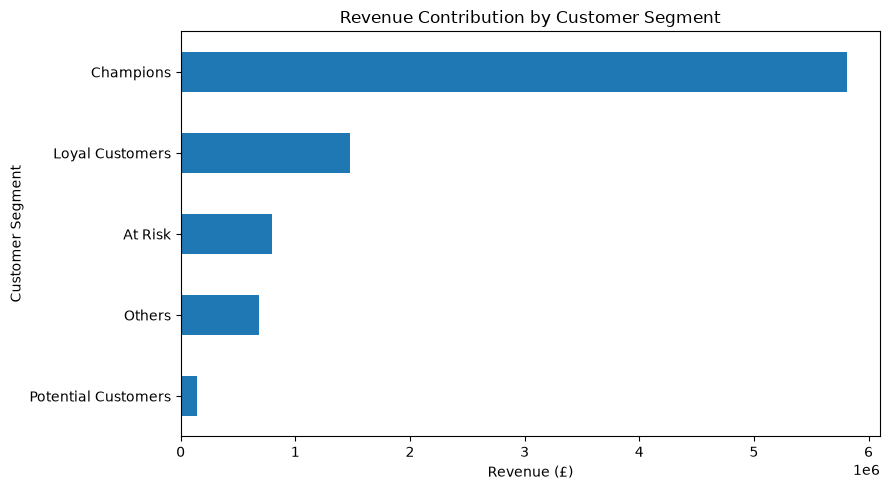

In [38]:
import matplotlib.pyplot as plt

segment_summary["Revenue"].sort_values().plot(
    kind="barh",
    figsize=(9, 5)
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer Segment")
plt.tight_layout()
plt.show()

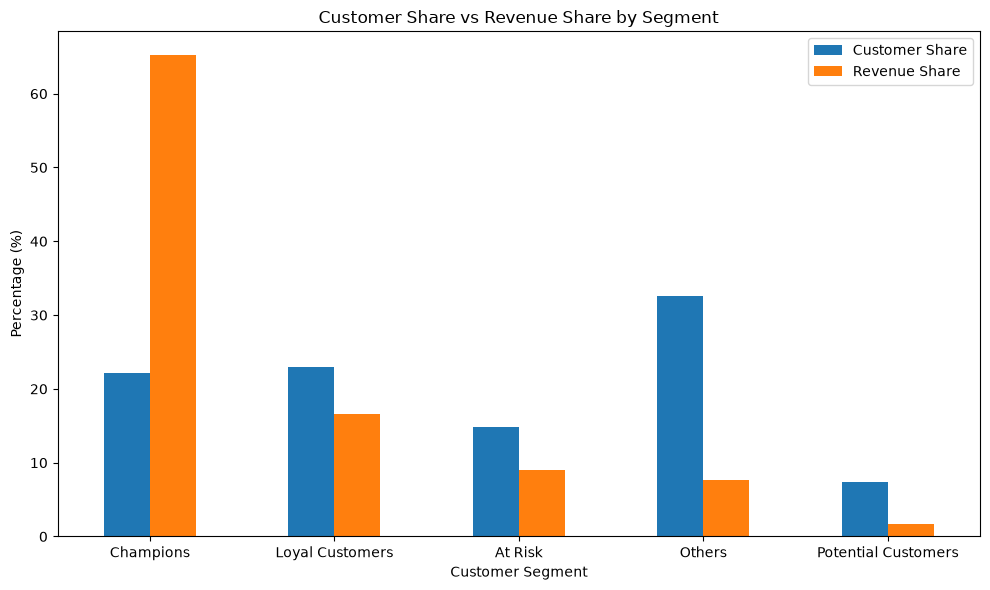

In [39]:
comparison = segment_summary[["Customer_%", "Revenue_%"]].sort_values(
    "Revenue_%", ascending=False
)

comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Customer Share vs Revenue Share by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(["Customer Share", "Revenue Share"])
plt.tight_layout()
plt.show()

In [40]:
at_risk = rfm[rfm["Segment"] == "At Risk"].copy()

at_risk.sort_values(
    "Monetary",
    ascending=False
).head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
15749.0,234,3,44534.30,1,3,5,9,At Risk
15098.0,181,3,39916.50,1,3,5,9,At Risk
12409.0,78,3,11072.67,2,3,5,10,At Risk
16180.0,99,8,10254.18,2,5,5,12,At Risk
13093.0,275,8,7832.47,1,5,5,11,At Risk
12980.0,157,9,7374.90,2,5,5,12,At Risk
16745.0,86,17,7194.30,2,5,5,12,At Risk
13027.0,113,6,6912.00,2,5,5,12,At Risk
15939.0,89,15,6115.01,2,5,5,12,At Risk


In [41]:
at_risk["Monetary"].describe()

count      643.000000
mean      1244.994636
std       2583.595821
min         52.000000
25%        430.405000
50%        724.760000
75%       1341.175000
max      44534.300000
Name: Monetary, dtype: float64

In [42]:
top_20_cutoff = int(len(at_risk) * 0.20)

top_at_risk_revenue = (
    at_risk.sort_values("Monetary", ascending=False)
    .head(top_20_cutoff)["Monetary"]
    .sum()
)

total_at_risk_revenue = at_risk["Monetary"].sum()

print("Top 20% At-Risk customers:", top_20_cutoff)
print("Their historical revenue: £{:,.2f}".format(top_at_risk_revenue))
print("Share of At-Risk revenue: {:.1f}%".format(
    top_at_risk_revenue / total_at_risk_revenue * 100
))

Top 20% At-Risk customers: 128
Their historical revenue: £450,174.11
Share of At-Risk revenue: 56.2%


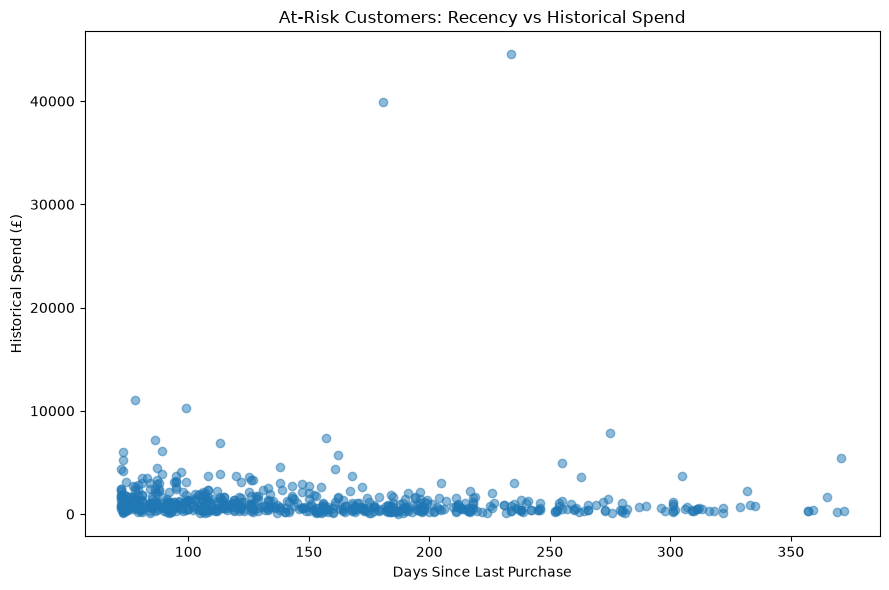

In [43]:
plt.figure(figsize=(9, 6))

plt.scatter(
    at_risk["Recency"],
    at_risk["Monetary"],
    alpha=0.5
)

plt.xlabel("Days Since Last Purchase")
plt.ylabel("Historical Spend (£)")
plt.title("At-Risk Customers: Recency vs Historical Spend")

plt.tight_layout()
plt.show()

In [44]:
comparison = rfm[rfm["Segment"].isin(["Champions", "At Risk"])].groupby("Segment").agg(
    Customers=("Monetary", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Spend=("Monetary", "mean"),
    Median_Spend=("Monetary", "median")
)

comparison

,Customers,Avg_Recency,Avg_Frequency,Avg_Spend,Median_Spend
Segment,,,,,
At Risk,643,151.844479,3.404355,1244.994636,724.76
Champions,962,11.861746,11.080042,6038.816081,2633.43


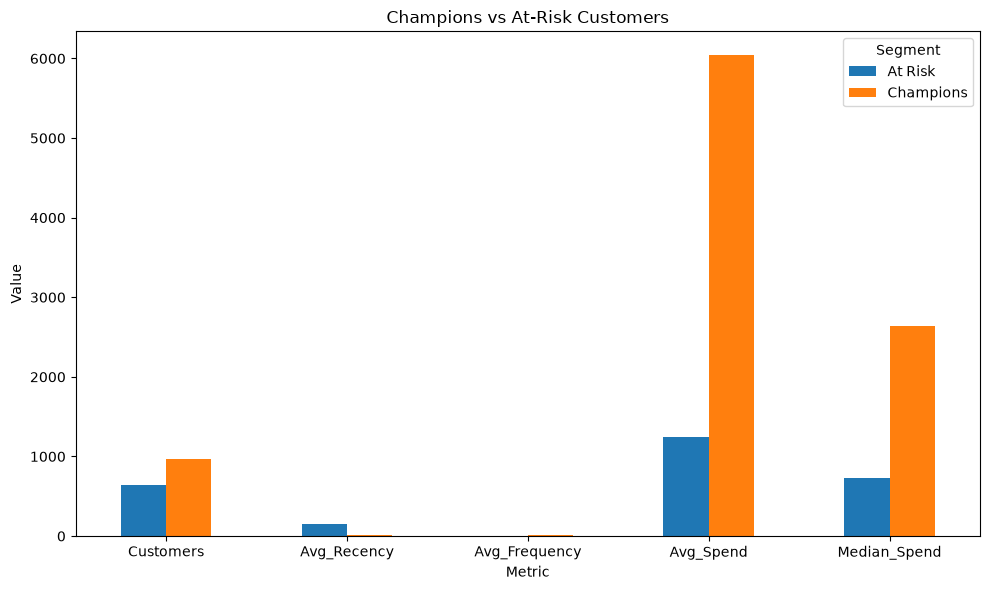

In [45]:
comparison.T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Champions vs At-Risk Customers")
plt.ylabel("Value")
plt.xlabel("Metric")
plt.xticks(rotation=0)
plt.legend(title="Segment")
plt.tight_layout()
plt.show()

## 6. Business Recommendations

### 1. Protect Champions

Champions represent 22.2% of customers but generate 65.2% of revenue.

**Recommendation:** Prioritize retention and loyalty initiatives for this group.

### 2. Prioritize High-Value At-Risk Customers

The top 20% of At-Risk customers account for 56.2% of the segment's historical revenue.

**Recommendation:** Target high-value At-Risk customers with personalized reactivation campaigns rather than treating the entire segment equally.

### 3. Convert Potential Customers

Potential Customers are recent purchasers who have not yet developed strong purchase frequency.

**Recommendation:** Encourage a second purchase through targeted offers and product recommendations.